# Setup

## Imports

In [1]:
import geopandas as gpd
import os
from pathlib import Path
import glob

# Change working directory first so local imports resolve correctly
os.chdir('/home/jovyan/JupyterRoot/Projects/RHIP')

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import scipy.stats as stats
import scikit_posthocs as sp
import statsmodels.formula.api as smf

import libpysal
import esda
import spreg
from esda.moran import Moran, Moran_Local
from spreg import ML_Lag

from utils import CensusDataLoader, ERSDataLoader

load_dotenv()

True

## Config

In [2]:
YEARS = [2013, 2018, 2023]

ACS_CACHE_PATH = Path(".data/RSS_ACS_DATA.csv")
ICE_DATA_DIR = Path("ice-detention-trends/facilities/by_fiscal_year")
METADATA_DIR = Path("ice-detention-trends/metadata")

# Data Collection

In [3]:
acs_loader = CensusDataLoader(api_key=os.getenv("CENSUS_API_KEY"))
ers_loader = ERSDataLoader(continental=True)

Census API key has been set for this session.
Getting data from the 2018-2022 5-year ACS


## RUCC Data

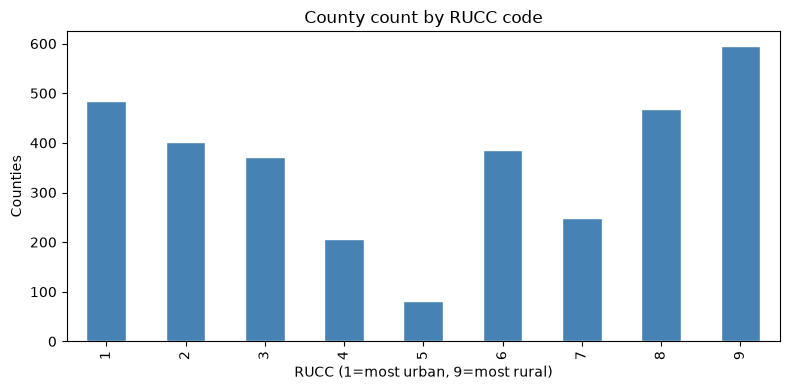

,GEOID,State,County_Name,Description,Population_2020,RUCC
0,1001,AL,autauga,"Metro - Counties in metro areas of 250,000 to ...",58805,2
1,1003,AL,baldwin,Metro - Counties in metro areas of fewer than ...,231767,3
2,1005,AL,barbour,"Nonmetro - Urban population of 5,000 to 20,000...",25223,6
3,1007,AL,bibb,Metro - Counties in metro areas of 1 million p...,22293,1
4,1009,AL,blount,Metro - Counties in metro areas of 1 million p...,59134,1


In [4]:
rucc_data = ers_loader.collect_rucc_data()
rucc_data.dropna(subset=['GEOID', 'RUCC'], inplace=True)
rucc_data["Population_2020"] = rucc_data["Population_2020"].fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
rucc_data['RUCC'].dropna().astype(int).value_counts().sort_index().plot(
    kind='bar', ax=ax, color='steelblue', edgecolor='white'
)
ax.set_title('County count by RUCC code')
ax.set_xlabel('RUCC (1=most urban, 9=most rural)')
ax.set_ylabel('Counties')
plt.tight_layout()
plt.show()

rucc_data.head()

In [ ]:
summary = rucc_data.loc[rucc_data['Population_2020'] <= 65000].groupby('RUCC')['Population_2020'].agg(count='count', average_population='mean')
summary['percentage'] = ((summary['count'] / rucc_data.groupby('RUCC').size()) * 100)

round(summary)

,count,average_population,percentage
RUCC,,,
1,178,30486.0,37.0
2,181,28216.0,45.0
3,176,24150.0,47.0
4,116,46688.0,56.0
5,60,43830.0,74.0
6,379,29465.0,98.0
7,247,24293.0,100.0
8,467,13073.0,100.0
9,595,7652.0,100.0


In [6]:
summary = rucc_data.loc[rucc_data['Population_2020'] <= 20000].groupby('RUCC')['Population_2020'].agg(count='count', average_population='mean')
summary['percentage'] = ((summary['count'] / rucc_data.groupby('RUCC').size()) * 100)

round(summary)

,count,average_population,percentage
RUCC,,,
1,51,12160.0,11.0
2,68,11757.0,17.0
3,83,11633.0,22.0
4,4,3371.0,2.0
6,102,15308.0,26.0
7,97,13689.0,39.0
8,387,10014.0,83.0
9,568,6763.0,95.0


## County Shapefile Data

Since the `Pygris` library the collect_geometry_data function uses is basically a wrapper for getting Census Bureau Shape Files, the only columns needed from this dataframe are `GEOID` and `geometry` which provides the polygon objects that geopandas uses for spatial analylsis.

In [7]:
if "county_geo" not in locals():
    county_geo = acs_loader.collect_geometry_data(geometry_type="counties", year=2021)
    
county_geo.head()

,GEOID,STATE,COUNTY,geometry
0,2090,AK,Fairbanks North Star Borough,"POLYGON ((-148.66326 64.59079, -148.64821 64.5..."
1,2275,AK,Wrangell City and Borough,"MULTIPOLYGON (((-132.0696 56.03168, -132.06865..."
2,2122,AK,Kenai Peninsula Borough,"MULTIPOLYGON (((-149.28378 59.86125, -149.2817..."
3,2066,AK,Copper River Census Area,"POLYGON ((-147.7443 61.42628, -147.71096 61.42..."
4,2185,AK,North Slope Borough,"MULTIPOLYGON (((-144.93708 69.98938, -144.9344..."


## Vira Data


### Facilities

Facilities are processed by first reading in the csv from the Vira data directory. The latitude and longitude points are used to convert `facilities` to a geodataframe. 

  Facilities with county match: 1473/1490 (98.86)


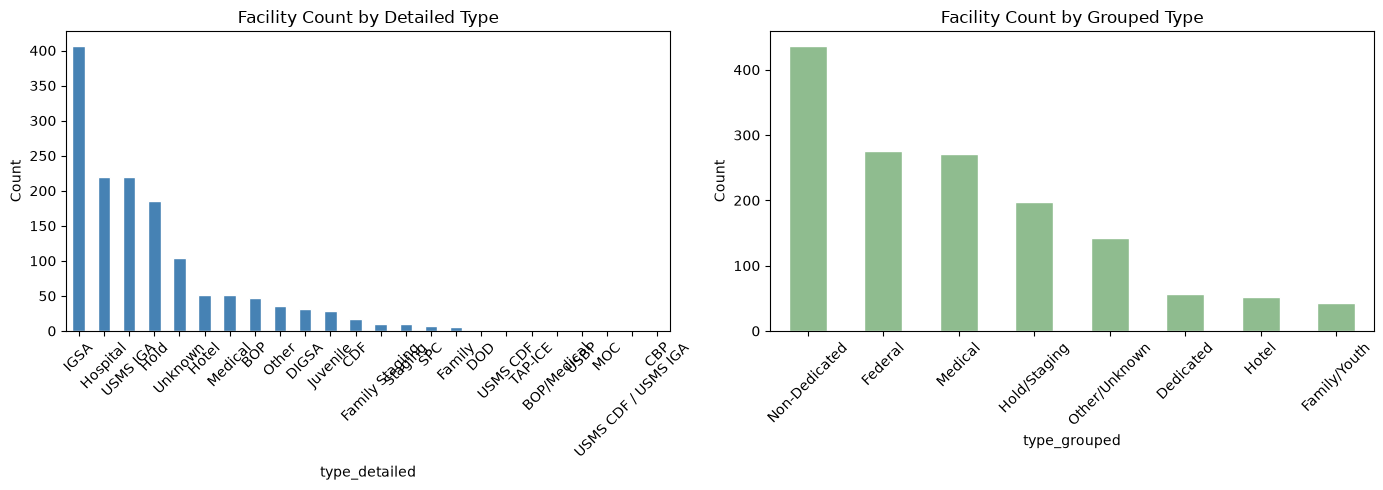

,detention_facility_code,detention_facility_name,type_detailed,type_grouped,coordinates,GEOID
0,AAORDMD,Ordnance Road Correctional Center,IGSA,Non-Dedicated,POINT (-76.59416 39.19961),24003.0
1,ABIRJVA,B.R.R.J. Abingdon,Unknown,Other/Unknown,POINT (-81.91164 36.73244),51191.0
2,ABQHOLD,Albuquerque Hold Room,Hold,Hold/Staging,POINT (-106.62703 35.05226),35001.0
3,ABRMCTX,Abilene Regional Med Ctr,Hospital,Medical,POINT (-99.74385 32.37501),48441.0
4,ABRXSPA,Abraxas Academy Detention Center,Juvenile,Family/Youth,POINT (-75.91592 40.19178),42011.0


In [8]:
if "facilities" not in locals():
    # Load facility data   
    facilities = pd.read_csv(METADATA_DIR / "facilities.csv")
    facilities = gpd.GeoDataFrame(
        facilities,
        geometry=gpd.points_from_xy(facilities.longitude, facilities.latitude),
        crs="EPSG:4326",
    )

    facilities = gpd.sjoin(
        facilities,
        county_geo[["GEOID", "geometry"]],
        how="left",
        predicate="within",
    )

    facilities = facilities.drop_duplicates(subset="detention_facility_code")

    n_matched = facilities.GEOID.notna().sum()
    print(f"  Facilities with county match: {n_matched}/{len(facilities)} ({round(n_matched / len(facilities) * 100, 2)})")

    facilities.dropna(subset="GEOID", inplace=True)

    cols = ['address', 'city', 'latitude', 'longitude',
       'county', 'state', 'zip', 'aor', 'index_right']
    facilities.drop(columns=cols, inplace=True)
    facilities = facilities.rename_geometry("coordinates")

# Plot distribution of facility types (detailed vs grouped)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

facilities["type_detailed"].value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("Facility Count by Detailed Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

facilities["type_grouped"].value_counts().plot(
    kind="bar", ax=axes[1], color="darkseagreen", edgecolor="white"
)
axes[1].set_title("Facility Count by Grouped Type")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

facilities.head()

### Incarceration Data

In [9]:
if "detention_data" not in locals():
    print("Processing Vira data")
    dfs = []
    for yr in YEARS:
        fp = ICE_DATA_DIR / f"FY{yr}.csv"
        if not fp.exists():
            print(f"  WARN: {fp} not found, skipping")
            continue
        df = pd.read_csv(fp)
        df["fiscal_year"] = yr
        dfs.append(df)
    
    detention_data = pd.concat(dfs, ignore_index=True)
    
    # Group by facility and year (some facilities have multiple rows per year)
    detention_data = detention_data.groupby(
        ["detention_facility_code", "fiscal_year"]
    ).agg({"daily_pop": "mean", "midnight_pop": "mean"}).reset_index()
    
    detention_data = detention_data.merge(
        facilities,
        on="detention_facility_code",
        how="left",
    )
else:
    print("Vira data already loaded")

detention_data.head()

Processing Vira data


,detention_facility_code,fiscal_year,daily_pop,midnight_pop,detention_facility_name,type_detailed,type_grouped,coordinates,GEOID
0,AAORDMD,2013,0.000000,0.000000,Ordnance Road Correctional Center,IGSA,Non-Dedicated,POINT (-76.59416 39.19961),24003.0
1,AAORDMD,2018,74.506849,73.473973,Ordnance Road Correctional Center,IGSA,Non-Dedicated,POINT (-76.59416 39.19961),24003.0
2,AAORDMD,2023,0.000000,0.000000,Ordnance Road Correctional Center,IGSA,Non-Dedicated,POINT (-76.59416 39.19961),24003.0
3,ABIRJVA,2013,0.000000,0.000000,B.R.R.J. Abingdon,Unknown,Other/Unknown,POINT (-81.91164 36.73244),51191.0
4,ABIRJVA,2018,0.000000,0.000000,B.R.R.J. Abingdon,Unknown,Other/Unknown,POINT (-81.91164 36.73244),51191.0


## ACS Data

- `MOBILITY_VARS`: Variables for calculating the percentage of the population below the poverty line that moved in the last year as a measure of housing stability in an area.

- `SNAP_VARS`: Variables for calculating the percentage of households that recieve SNAP benefits out of the total number of households.

- `EMPLOYMENT_VARS`: Variables for calculating the percentage of people considered to be in the labor force that are unemployed out of the total number of people in the labor force

- `EDUCATION_VARS`: Variables for calculating the percentage of people over 25 (honestly, no idea why this is the age minimum the Census Bureau uses) without a high school degree.

- `QUALITY_VARS`: Variables for calculating the percentage of occupied housing units with an incomplete kitchen or incomplete plumbing out of the total number of housing units

- `POVERTY_VARS`: Variables for calculating the poverty rate of an area

- `MORTGAGE_VARS`/`RENT_VARS`: variables for calculating the percentage of households in an area that spend more than 30% of their income on housing.

- `MISC_VARS`: Just needed to sneak the household Gini index variable in somewhere

In [10]:
MOBILITY_VARS = {
    "MOBILITY_TOTAL": "B07012_002E",
    # NOTE: `SAME_HOUSE` isn't needed because only want people that moved factored into percentage
    "MOVED_SAME_COUNTY": "B07012_010E",
    "MOVED_DIFF_COUNTY": "B07012_014E",
    "MOVED_DIFF_STATE": "B07012_018E",
    "MOVED_ABROAD": "B07012_022E",
}
SNAP_VARS = {"SNAP_TOTAL": "B22003_001E", "RECEIVING": "B22003_002E"}
EMPLOYMENT_VARS = {"LABOR_FORCE": "B23025_002E", "UNEMPLOYED": "B23025_005E"}
EDUCATION_VARS = {
    "EDU_TOTAL": "B15003_001E",
    "GRADES": [f"B15003_{num:03d}E" for num in range(2, 17)],
}
QUALITY_VARS = { 
    "KITCH_TOTAL": "B25051_001E",
    "LACK_KITCHEN": "B25051_003E",
}
POVERTY_VARS = {"POV_TOTAL": "B17001_001E", "POVERTY": "B17001_002E"}
MORTGAGE_VARS = {
    "MORT_TOTAL": "B25091_001E",
    "MORT_30_35": "B25091_008E",
    "MORT_35_40": "B25091_009E",
    "MORT_40_50": "B25091_010E",
    "MORT_50_PLUS": "B25091_011E",
    "NO_MORT_30_35": "B25091_019E",
    "NO_MORT_35_40": "B25091_020E",
    "NO_MORT_40_50": "B25091_021E",
    "NO_MORT_50_PLUS": "B25091_022E",
}
RENT_VARS = {
    "RENT_TOTAL": "B25070_001E",
    "RENT_30_35": "B25070_007E",
    "RENT_35_40": "B25070_008E",
    "RENT_40_50": "B25070_009E",
    "RENT_50_PLUS": "B25070_010E",
}
MISC_VARS = {"GINI": "B19083_001E", "TOTAL_POP": "B01003_001E"}

In [11]:
# Flatten all var dicts into one lookup
all_vars_dict: dict[str, str] = {}
for d in [
    MOBILITY_VARS, SNAP_VARS, EMPLOYMENT_VARS, EDUCATION_VARS,
    QUALITY_VARS, POVERTY_VARS, MORTGAGE_VARS, RENT_VARS, MISC_VARS,
]:
    for key, val in d.items():
        if isinstance(val, list):
            for i, item in enumerate(val):
                all_vars_dict[f"{key}_{i}"] = item
        else:
            all_vars_dict[key] = val

In [12]:
CACHE: bool = True # set to false to ignore existing csv file for data

if ACS_CACHE_PATH.exists() and CACHE is True:
    print("Loading cached ACS data from", ACS_CACHE_PATH)
    acs_data = pd.read_csv(ACS_CACHE_PATH)
else:
    print("Fetching ACS data from Census API...")
    acs_data = acs_loader.fetch_multiple_years(
        years=YEARS,
        variables=all_vars_dict,
        geography="county",
    )
    ACS_CACHE_PATH.parent.mkdir(exist_ok=True)
    acs_data.to_csv(ACS_CACHE_PATH, index=False)
    print(f"Saved ACS data to {ACS_CACHE_PATH}")

acs_data.head()

Loading cached ACS data from .data/RSS_ACS_DATA.csv


,GEOID,MOBILITY_TOTAL,MOVED_SAME_COUNTY,MOVED_DIFF_COUNTY,MOVED_DIFF_STATE,MOVED_ABROAD,SNAP_TOTAL,RECEIVING,LABOR_FORCE,UNEMPLOYED,...,NO_MORT_40_50,NO_MORT_50_PLUS,RENT_TOTAL,RENT_30_35,RENT_35_40,RENT_40_50,RENT_50_PLUS,GINI,TOTAL_POP,year
0,1001,6546.0,1073.0,232.0,212.0,0.0,20071,2307,27101.0,2481.0,...,85.0,418.0,4653.0,589.0,339.0,208.0,1033.0,0.4031,54907,2013
1,1003,25313.0,5026.0,1598.0,1497.0,399.0,73283,6579,90579.0,8327.0,...,529.0,796.0,20058.0,1729.0,1726.0,2147.0,3902.0,0.4455,187114,2013
2,1005,6365.0,686.0,53.0,206.0,94.0,9200,2105,10903.0,1559.0,...,128.0,191.0,2973.0,154.0,149.0,193.0,693.0,0.4658,27321,2013
3,1007,3833.0,326.0,219.0,216.0,0.0,7091,1194,9144.0,1116.0,...,119.0,104.0,1492.0,109.0,85.0,121.0,361.0,0.4500,22754,2013
4,1009,8835.0,1042.0,564.0,65.0,26.0,21108,2788,25523.0,2483.0,...,215.0,313.0,4000.0,198.0,162.0,193.0,601.0,0.4144,57623,2013


In [13]:
acs_data["RiskyMobility"] = (
    acs_data["MOVED_DIFF_COUNTY"] + acs_data["MOVED_DIFF_STATE"]
    + acs_data["MOVED_ABROAD"]
) / acs_data["MOBILITY_TOTAL"].replace(0, np.nan)

acs_data["SnapRate"] = acs_data["RECEIVING"] / acs_data["SNAP_TOTAL"].replace(0, np.nan)

acs_data["Unemployment"] = (
    acs_data["UNEMPLOYED"] / acs_data["LABOR_FORCE"].replace(0, np.nan)
)

hs_grades = [
    "GRADES_0", "GRADES_1", "GRADES_2", "GRADES_3", "GRADES_4",
    "GRADES_5", "GRADES_6", "GRADES_7", "GRADES_8", "GRADES_9",
    "GRADES_10", "GRADES_11", "GRADES_12", "GRADES_13", "GRADES_14",
]
acs_data["No_HS"] = (
    acs_data[hs_grades].sum(axis=1)
    / acs_data["EDU_TOTAL"].replace(0, np.nan)
)

acs_data["HousingQuality"] = (
    acs_data["LACK_KITCHEN"]
    / acs_data["KITCH_TOTAL"]).replace(0, np.nan)


acs_data["Poverty"] = (
    acs_data["POVERTY"] / acs_data["POV_TOTAL"].replace(0, np.nan)
)

cost_cols = [
    "MORT_30_35", "MORT_35_40", "MORT_40_50", "MORT_50_PLUS",
    "NO_MORT_30_35", "NO_MORT_35_40", "NO_MORT_40_50", "NO_MORT_50_PLUS",
    "RENT_30_35", "RENT_35_40", "RENT_40_50", "RENT_50_PLUS",
]
acs_data["CostBurden"] = (
    acs_data[cost_cols].sum(axis=1)
    / (acs_data["MORT_TOTAL"] + acs_data["RENT_TOTAL"]).replace(0, np.nan)
)


In [14]:
drop_cols = ['MOVED_SAME_COUNTY', 'MOVED_DIFF_COUNTY', 'MOVED_DIFF_STATE', 'MOVED_ABROAD', 'SNAP_TOTAL', 'RECEIVING', 'LABOR_FORCE', 'UNEMPLOYED', 'EDU_TOTAL', 'GRADES_0', 'GRADES_1', 'GRADES_2', 'GRADES_3', 'GRADES_4', 'GRADES_5', 'GRADES_6', 'GRADES_7', 'GRADES_8', 'GRADES_9', 'GRADES_10', 'GRADES_11', 'GRADES_12', 'GRADES_13', 'GRADES_14', 'KITCH_TOTAL', 'LACK_KITCHEN', 'POV_TOTAL', 'POVERTY', 'MORT_TOTAL', 'MORT_30_35', 'MORT_35_40', 'MORT_40_50', 'MORT_50_PLUS', 'NO_MORT_30_35', 'NO_MORT_35_40', 'NO_MORT_40_50', 'NO_MORT_50_PLUS', 'RENT_TOTAL', 'RENT_30_35', 'RENT_35_40', 'RENT_40_50', 'RENT_50_PLUS', 'state', 'county', 'NAME', 'MOBILITY_TOTAL']

acs_data.rename(columns={'TOTAL_POP': 'TotalPopulation'}, inplace=True)
acs_data.drop(columns=[col for col in drop_cols if col in acs_data.columns], inplace=True)

_CT_PR_TO_COUNTY = {
    9110: 9003, 9120: 9001, 9130: 9007, 9140: 9009,
    9150: 9015, 9160: 9005, 9170: 9009, 9180: 9011, 9190: 9001
}
if 2023 in acs_data['year'].values:
    ct_mask = (acs_data['year'] == 2023) & (acs_data['GEOID'] >= 9110) & (acs_data['GEOID'] <= 9190)
    acs_data.loc[ct_mask, 'GEOID'] = acs_data.loc[ct_mask, 'GEOID'].map(_CT_PR_TO_COUNTY)
    acs_data = acs_data.groupby(['year', 'GEOID']).mean(numeric_only=True).reset_index()

acs_data.head()

,year,GEOID,GINI,TotalPopulation,RiskyMobility,SnapRate,Unemployment,No_HS,HousingQuality,Poverty,CostBurden
0,2013,1001,0.4031,54907.0,0.067828,0.114942,0.091546,0.144078,0.029433,0.121334,0.289622
1,2013,1003,0.4455,187114.0,0.138032,0.089775,0.091931,0.109247,0.026365,0.139407,0.305883
2,2013,1005,0.4658,27321.0,0.055460,0.228804,0.142988,0.263430,0.030110,0.266568,0.300543
3,2013,1007,0.4500,22754.0,0.113488,0.168382,0.122047,0.225489,0.044748,0.181378,0.271471
4,2013,1009,0.4144,57623.0,0.074137,0.132083,0.097285,0.230062,0.034207,0.158112,0.247110


In [15]:
df = acs_data.merge(right=county_geo, how='left', on='GEOID')
df = df.merge(right=rucc_data[['GEOID', 'RUCC']], how='left', on='GEOID')
df = df.merge(
    right=detention_data.assign(GEOID=detention_data['GEOID'].astype('Int64')),
    how='left',
    left_on=['year', 'GEOID'],
    right_on=['fiscal_year', 'GEOID'],
)
df = df.drop(columns=['fiscal_year'])

# Filter out non-continental states/territories (AK, HI, PR)
df = df[~df['STATE'].isin(['AK', 'HI', 'PR'])]

# Drop dissolved FIPS that appear in ACS but no longer exist as geographic entities
# (e.g. Bedford City VA 51515, absorbed into Bedford County 51019 in 2013)
_DISSOLVED_FIPS = {51515}
df = df[~df['GEOID'].isin(_DISSOLVED_FIPS)]

df['daily_change'] = df['daily_pop'] - df['midnight_pop']

# Compute per-100k detention and turnover rates
df['detention_rate'] = (df['daily_pop'].fillna(0) / df['TotalPopulation']) * 100_000
df['turnover_rate'] = (df['daily_change'].fillna(0) / df['TotalPopulation']) * 100_000

df = df.set_index(['year', 'GEOID'])

print(f'Shape: {df.shape}, NaN RUCC: {df["RUCC"].isna().sum()}')
df.head()

Shape: (11483, 23), NaN RUCC: 4


GINI  TotalPopulation  RiskyMobility  SnapRate  Unemployment  \
year GEOID                                                                   
2013 1001   0.4031          54907.0       0.067828  0.114942      0.091546   
     1003   0.4455         187114.0       0.138032  0.089775      0.091931   
     1005   0.4658          27321.0       0.055460  0.228804      0.142988   
     1007   0.4500          22754.0       0.113488  0.168382      0.122047   
     1009   0.4144          57623.0       0.074137  0.132083      0.097285   

               No_HS  HousingQuality   Poverty  CostBurden STATE  ...  \
year GEOID                                                        ...   
2013 1001   0.144078        0.029433  0.121334    0.289622    AL  ...   
     1003   0.109247        0.026365  0.139407    0.305883    AL  ...   
     1005   0.263430        0.030110  0.266568    0.300543    AL  ...   
     1007   0.225489        0.044748  0.181378    0.271471    AL  ...   
     1009   0.230062        0.034207  0.158112    0.247110    AL  ...   

           detention_facility_code daily_pop midnight_pop  \
year GEOID                                                  
2013 1001                      NaN       NaN          NaN   
     1003                  BALDWAL  2.753425          1.8   
     1005                      NaN       NaN          NaN   
     1007                      NaN       NaN          NaN   
     1009                      NaN       NaN          NaN   

               detention_facility_name  type_detailed   type_grouped  \
year GEOID                                                             
2013 1001                          NaN            NaN            NaN   
     1003   Baldwin County Cor. Center           IGSA  Non-Dedicated   
     1005                          NaN            NaN            NaN   
     1007                          NaN            NaN            NaN   
     1009                          NaN            NaN            NaN   

                          coordinates daily_change detention_rate  \
year GEOID                                                          
2013 1001                        None          NaN       0.000000   
     1003   POINT (-87.77479 30.8853)     0.953425       1.471523   
     1005                        None          NaN       0.000000   
     1007                        None          NaN       0.000000   
     1009                        None          NaN       0.000000   

           turnover_rate  
year GEOID                
2013 1001       0.000000  
     1003       0.509542  
     1005       0.000000  
     1007       0.000000  
     1009       0.000000  

[5 rows x 23 columns]

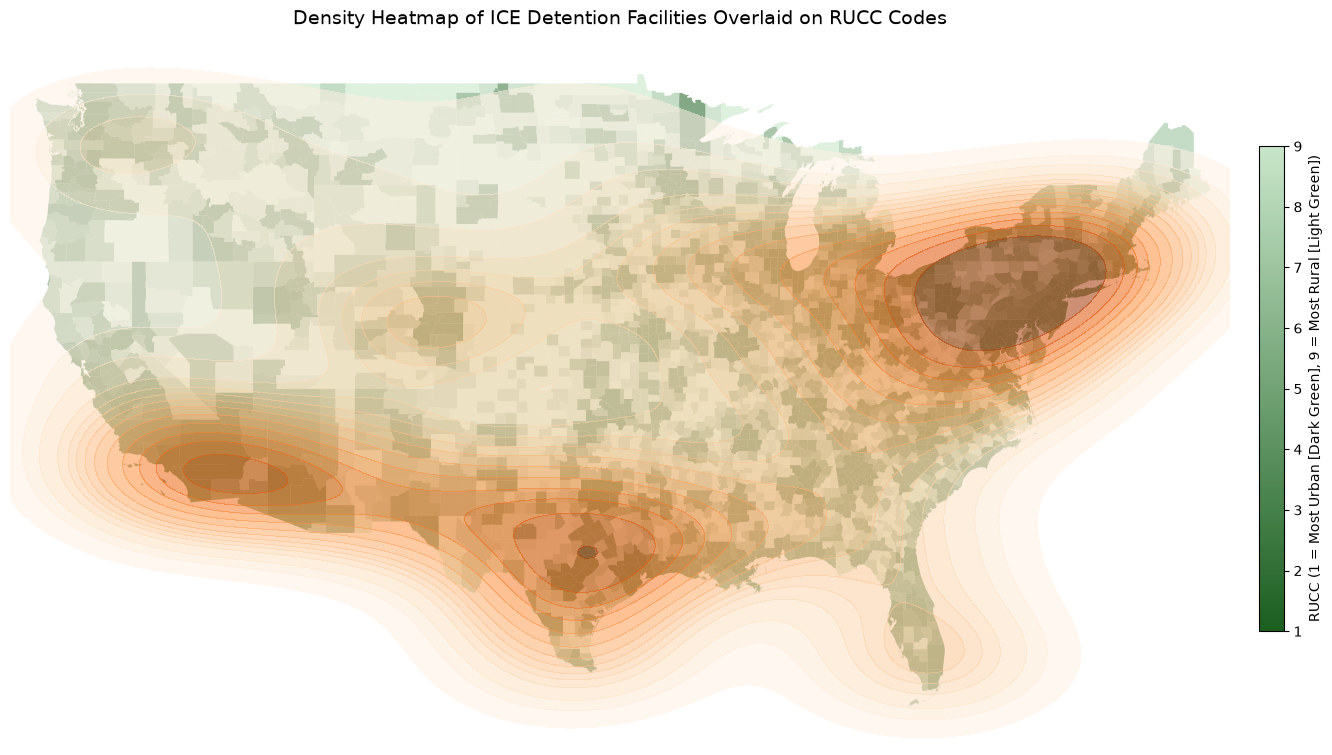

In [16]:
# Create facility density heatmap overlaid on county geometries (filtered to continental US)
import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(15, 10))

# Filter county geometries to continental US states (excluding AK, HI, PR)
continental_geo = county_geo[
    (county_geo['STATE'] != 'AK') & 
    (county_geo['STATE'] != 'HI') & 
    (county_geo['STATE'] != 'PR')
].copy()

# Cast GEOID to int and merge with rucc_data to get RUCC codes for coloring
continental_geo['GEOID'] = continental_geo['GEOID'].astype(int)
continental_geo = continental_geo.merge(rucc_data[['GEOID', 'RUCC']], on='GEOID', how='left')

# Cast RUCC to float so geopandas correctly recognizes it as a continuous numeric column
continental_geo['RUCC'] = continental_geo['RUCC'].astype(float)

# Create RUCC colormap
custom_rucc_cmap = mcolors.LinearSegmentedColormap.from_list(
    "rucc_forest_to_mint", 
    ["#1b5e20", "#c8e6c9"]  # Dark forest green to soft mint green
)

# Plot base continental US counties colored by RUCC code (no county border lines)
continental_geo.plot(
    column='RUCC',
    cmap=custom_rucc_cmap,
    edgecolor='none',
    ax=ax,
    alpha=0.6,
    categorical=False,
    legend=True,
    legend_kwds={'label': "RUCC (1 = Most Urban [Dark Green], 9 = Most Rural [Light Green])", 'shrink': 0.5, 'pad': 0.02}
)

# Filter facilities to continental US bounding box
fac_x = facilities.coordinates.x
fac_y = facilities.coordinates.y
cont_mask = (fac_x >= -125) & (fac_x <= -65) & (fac_y >= 24) & (fac_y <= 50)
continental_facilities = facilities[cont_mask].copy()

# Plot 2D KDE heatmap of facility density (pure density overlay on RUCC)
sns.kdeplot(
    x=continental_facilities.coordinates.x, y=continental_facilities.coordinates.y,
    ax=ax, fill=True, cmap='Oranges', alpha=0.55,
    levels=15, thresh=0.05
)

ax.set_title("Density Heatmap of ICE Detention Facilities Overlaid on RUCC Codes", fontsize=14)
ax.set_xlim(-126, -66)
ax.set_ylim(23, 51)
ax.axis('off')
plt.tight_layout()
plt.show()

In [17]:
# Cross-tabulate the counts of unique active facilities by RUCC code and Facility Type
facilities_with_rucc = df.reset_index().dropna(subset=['detention_facility_code']).drop_duplicates(subset=['detention_facility_code'])
crosstab_unique = pd.crosstab(
    facilities_with_rucc['RUCC'].astype(int), 
    facilities_with_rucc['type_grouped'],
    margins=True, 
    margins_name="Total"
)

print("=== Count of Unique Detention Facilities by RUCC and Grouped Type ===")
display(crosstab_unique)

=== Count of Unique Detention Facilities by RUCC and Grouped Type ===


type_grouped,Dedicated,Family/Youth,Federal,Hold/Staging,Hotel,Medical,Non-Dedicated,Other/Unknown,Total
RUCC,,,,,,,,,
1,18,11,83,73,32,165,124,43,549
2,13,13,63,64,14,47,74,43,331
3,3,7,45,32,4,23,61,20,195
4,4,1,16,5,0,11,34,4,75
5,0,3,8,4,0,3,14,4,36
6,8,3,23,6,1,8,41,12,102
7,2,1,16,5,0,3,25,4,56
8,7,3,11,3,0,3,24,8,59
9,1,0,6,0,0,1,28,3,39


# Data Analysis

In [18]:
SES_VARS = ['GINI', 'RiskyMobility', 'SnapRate', 'Unemployment', 'No_HS', 'HousingQuality', 'Poverty', 'CostBurden']
# Overall summary statistics across all county-years
df[SES_VARS].describe().round(4)

,GINI,RiskyMobility,SnapRate,Unemployment,No_HS,HousingQuality,Poverty,CostBurden
count,11482.0000,11482.0000,11483.0000,11482.0000,11483.0000,11472.0000,11482.0000,11482.0000
mean,0.4477,0.0929,0.1336,0.0659,0.1385,0.0422,0.1564,0.2678
std,0.0363,0.0575,0.0648,0.0345,0.0686,0.0310,0.0627,0.0745
min,0.2567,0.0000,0.0000,0.0000,0.0000,0.0006,0.0092,0.0000
25%,0.4228,0.0562,0.0868,0.0425,0.0884,0.0202,0.1123,0.2152
50%,0.4461,0.0816,0.1258,0.0592,0.1247,0.0339,0.1473,0.2583
75%,0.4694,0.1168,0.1691,0.0838,0.1748,0.0549,0.1894,0.3117
max,0.7095,0.7946,0.5351,0.3110,0.6634,0.3291,0.5510,0.5363


## Variable distributions

## SES by rurality (RUCC groups)

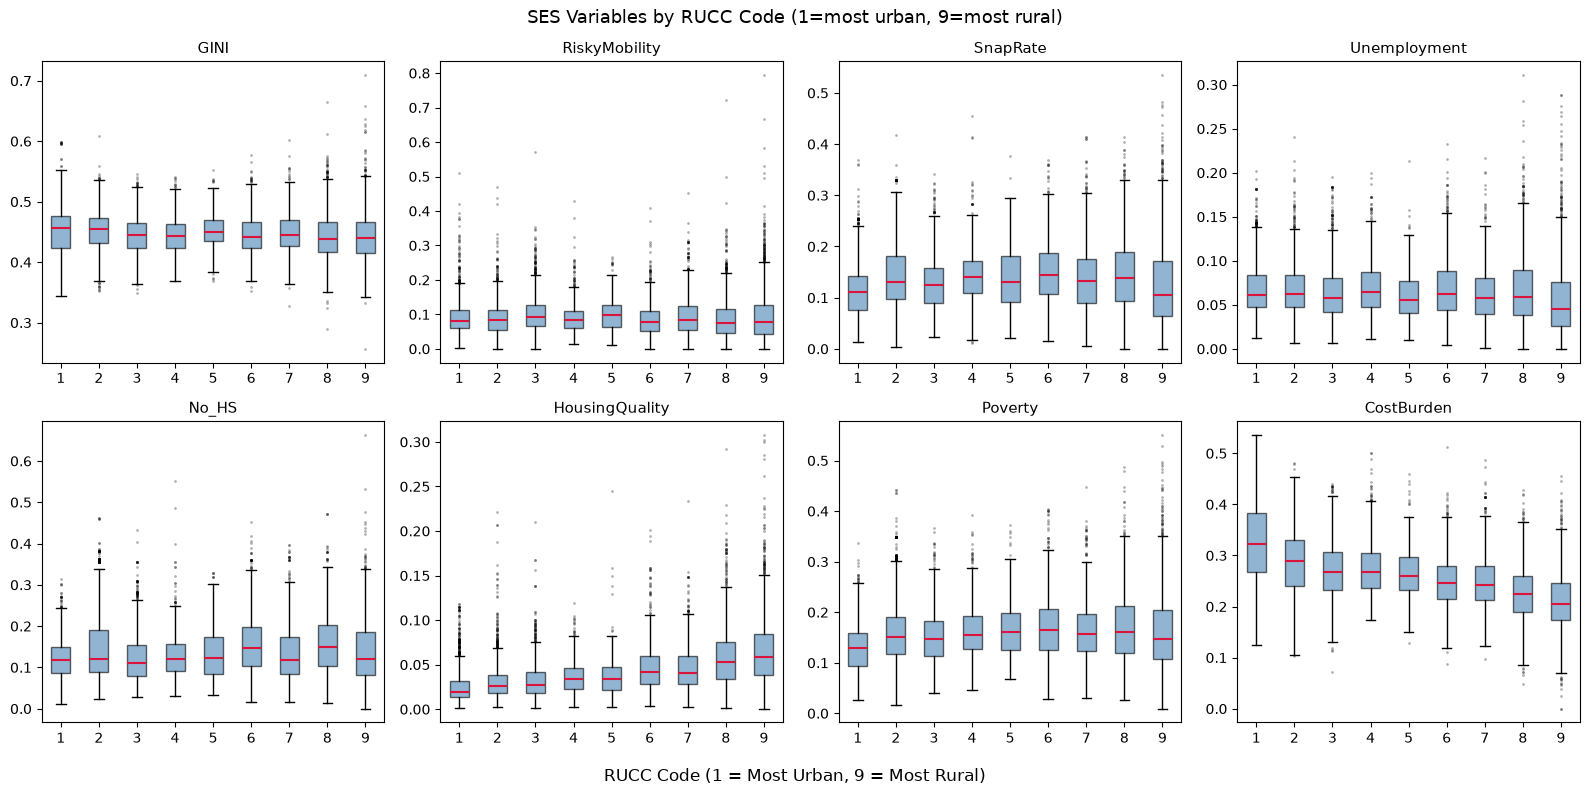

In [19]:
plot_df = df[SES_VARS + ['RUCC']].copy().dropna()
plot_df['RUCC'] = plot_df['RUCC'].astype(int)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('SES Variables by RUCC Code (1=most urban, 9=most rural)', fontsize=13, y=0.98)

for ax, var in zip(axes.flat, SES_VARS):
    data_by_rucc = [plot_df[plot_df['RUCC'] == r][var].dropna().values for r in range(1, 10)]
    ax.boxplot(data_by_rucc, tick_labels=range(1, 10), patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='crimson', linewidth=1.5),
               flierprops=dict(marker='.', markersize=2, alpha=0.3))
    ax.set_title(var, fontsize=11)

fig.supxlabel('RUCC Code (1 = Most Urban, 9 = Most Rural)', fontsize=12, y=0.01)

plt.tight_layout()
plt.show()

## Detention facility coverage

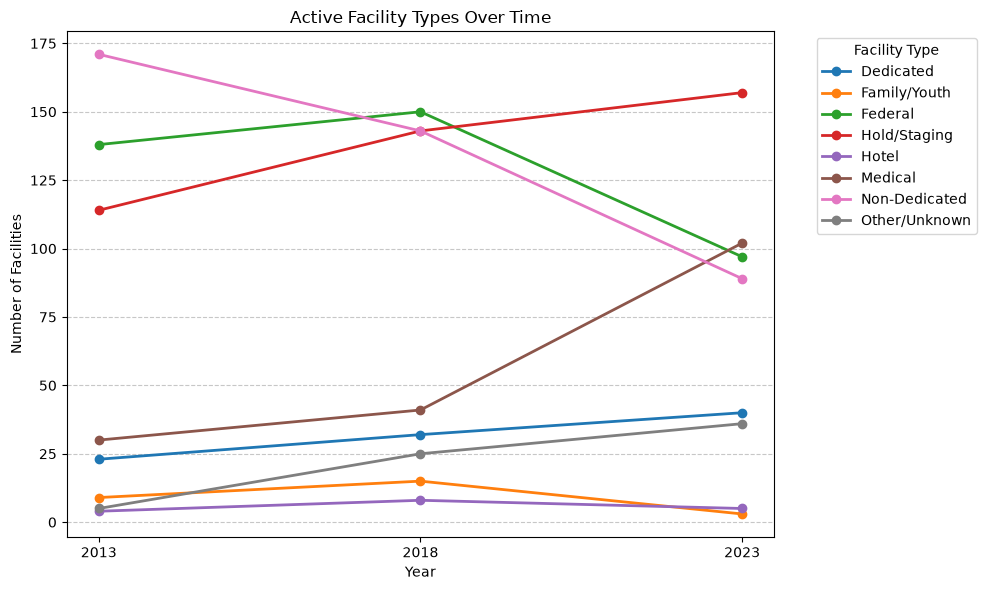

In [20]:
# Line plot of facility type over years
det = df.reset_index()
# Drop rows where RUCC is missing (if any) and cast to integer for plotting
det = det.dropna(subset=['RUCC']).copy()
det['RUCC'] = det['RUCC'].astype(int)

# Counties with any active facility (daily_pop > 0) per year
active = det[det['daily_pop'] > 0]

fac_type_yr = active.groupby(['year', 'type_grouped'])['detention_facility_code'].count().unstack('type_grouped').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
fac_type_yr.plot(kind='line', marker='o', ax=ax, linewidth=2)
ax.set_title('Active Facility Types Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Facilities')
ax.set_xticks(fac_type_yr.index)
ax.legend(title='Facility Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

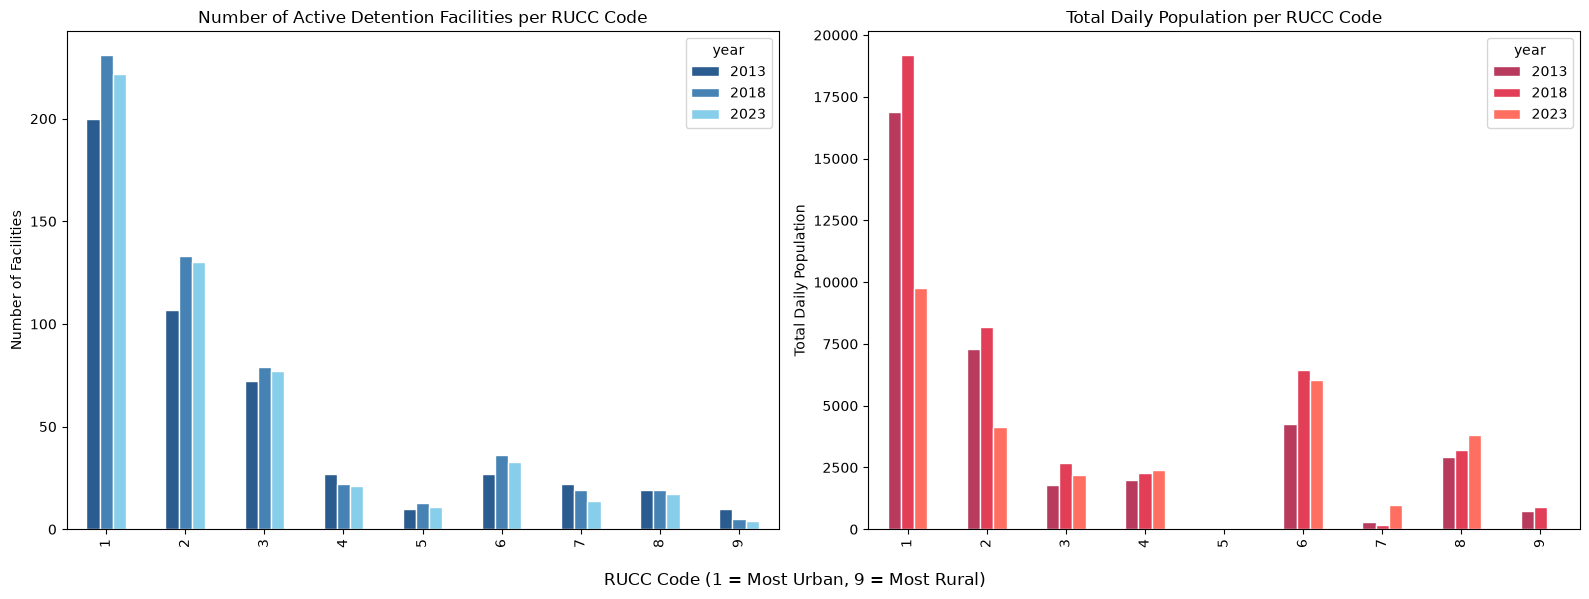

In [21]:
det = df.reset_index()
# Drop rows where RUCC is missing (if any) and cast to integer for plotting
det = det.dropna(subset=['RUCC']).copy()
det['RUCC'] = det['RUCC'].astype(int)

# Counties with any active facility (daily_pop > 0) per year
active = det[det['daily_pop'] > 0]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Number of detention facilities per RUCC code over the years
fac_by_rucc_yr = active.groupby(['RUCC', 'year'])['detention_facility_code'].count().unstack('year').fillna(0)
fac_by_rucc_yr.plot(kind='bar', ax=axes[0], color=['#2b5c8f', '#4682b4', '#87ceeb'], edgecolor='white')
axes[0].set_title('Number of Active Detention Facilities per RUCC Code')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Facilities')

# Plot 2: Total daily_pop per RUCC code over the years
pop_by_rucc_yr = active.groupby(['RUCC', 'year'])['daily_pop'].sum().unstack('year').fillna(0)
pop_by_rucc_yr.plot(kind='bar', ax=axes[1], color=['#b83b5e', '#e23e57', '#ff6f61'], edgecolor='white')
axes[1].set_title('Total Daily Population per RUCC Code')
axes[1].set_xlabel('')
axes[1].set_ylabel('Total Daily Population')

fig.supxlabel('RUCC Code (1 = Most Urban, 9 = Most Rural)', fontsize=12, y=0.01)

plt.tight_layout()
plt.show()

## Statistical Analysis: Detention Rates by RUCC

In [9]:
# Aggregate to the county-year level to resolve multiple facilities per county
df_flat = df.reset_index().dropna(subset=['RUCC']).copy()
df_flat['RUCC'] = df_flat['RUCC'].astype(int)

agg_dict = {
    'TotalPopulation': 'first',
    'GINI': 'first',
    'RiskyMobility': 'first',
    'SnapRate': 'first',
    'Unemployment': 'first',
    'No_HS': 'first',
    'HousingQuality': 'first',
    'Poverty': 'first',
    'CostBurden': 'first',
    'RUCC': 'first',
    'STATE': 'first',
    'COUNTY': 'first',
    'geometry': 'first',
    'daily_pop': 'sum',
    'midnight_pop': 'sum',
    'daily_change': 'sum',
    'detention_facility_code': 'nunique'
}

df_county = df_flat.groupby(['year', 'GEOID']).agg(agg_dict).reset_index()

# Re-compute rates at county level
df_county['detention_rate'] = (df_county['daily_pop'].fillna(0) / df_county['TotalPopulation']) * 100_000
df_county['turnover_rate'] = (df_county['daily_change'].fillna(0) / df_county['TotalPopulation']) * 100_000

print(f"Aggregated df_county shape: {df_county.shape}")
df_county.head()

KeyError: ['RUCC']

In [23]:
# Kruskal-Wallis H-test (per year)
for yr in [2013, 2018, 2023]:
    sub = df_county[df_county['year'] == yr]
    groups = [
        grp['detention_rate'].dropna().values
        for _, grp in sub.groupby('RUCC')
    ]
    stat, p = stats.kruskal(*groups)
    print(f"{yr}: H={stat:.2f}, p={p:.4f}")

2013: H=208.38, p=0.0000
2018: H=258.65, p=0.0000
2023: H=244.65, p=0.0000


In [24]:
# Dunn's post-hoc with Bonferroni correction (per year)
for yr in [2013, 2018, 2023]:
    sub = df_county[df_county['year'] == yr].dropna(subset=['detention_rate'])
    dunn = sp.posthoc_dunn(
        sub, val_col='detention_rate', group_col='RUCC', p_adjust='bonferroni'
    )
    print(f"\n--- {yr} Dunn's test (Bonferroni-corrected p-values) ---")
    display(dunn.style.background_gradient(cmap='RdYlGn_r', vmin=0, vmax=0.05))


--- 2013 Dunn's test (Bonferroni-corrected p-values) ---


,1,2,3,4,5,6,7,8,9
1,1.000000,0.228378,0.001430,0.000001,0.031860,0.000000,0.000000,0.000000,0.000000
2,0.228378,1.000000,1.000000,0.037332,1.000000,0.000000,0.000073,0.000000,0.000000
3,0.001430,1.000000,1.000000,1.000000,1.000000,0.000793,0.019359,0.000003,0.000000
4,0.000001,0.037332,1.000000,1.000000,1.000000,1.000000,1.000000,0.777174,0.042681
5,0.031860,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.346638
6,0.000000,0.000000,0.000793,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,0.000000,0.000073,0.019359,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,0.000000,0.000000,0.000003,0.777174,1.000000,1.000000,1.000000,1.000000,1.000000
9,0.000000,0.000000,0.000000,0.042681,0.346638,1.000000,1.000000,1.000000,1.000000



--- 2018 Dunn's test (Bonferroni-corrected p-values) ---


,1,2,3,4,5,6,7,8,9
1,1.000000,0.645168,0.000063,0.000000,0.021597,0.000000,0.000000,0.000000,0.000000
2,0.645168,1.000000,0.631067,0.000525,1.000000,0.000000,0.000000,0.000000,0.000000
3,0.000063,0.631067,1.000000,0.786886,1.000000,0.007591,0.004983,0.000000,0.000000
4,0.000000,0.000525,0.786886,1.000000,1.000000,1.000000,1.000000,0.584129,0.029935
5,0.021597,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.477313,0.074411
6,0.000000,0.000000,0.007591,1.000000,1.000000,1.000000,1.000000,1.000000,0.082907
7,0.000000,0.000000,0.004983,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,0.000000,0.000000,0.000000,0.584129,0.477313,1.000000,1.000000,1.000000,1.000000
9,0.000000,0.000000,0.000000,0.029935,0.074411,0.082907,1.000000,1.000000,1.000000



--- 2023 Dunn's test (Bonferroni-corrected p-values) ---


,1,2,3,4,5,6,7,8,9
1,1.000000,1.000000,0.013977,0.000000,0.025738,0.000000,0.000000,0.000000,0.000000
2,1.000000,1.000000,1.000000,0.000232,0.590105,0.000000,0.000000,0.000000,0.000000
3,0.013977,1.000000,1.000000,0.110888,1.000000,0.000492,0.000211,0.000000,0.000000
4,0.000000,0.000232,0.110888,1.000000,1.000000,1.000000,1.000000,0.912432,0.087059
5,0.025738,0.590105,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.250581
6,0.000000,0.000000,0.000492,1.000000,1.000000,1.000000,1.000000,1.000000,0.157646
7,0.000000,0.000000,0.000211,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
8,0.000000,0.000000,0.000000,0.912432,1.000000,1.000000,1.000000,1.000000,1.000000
9,0.000000,0.000000,0.000000,0.087059,0.250581,0.157646,1.000000,1.000000,1.000000


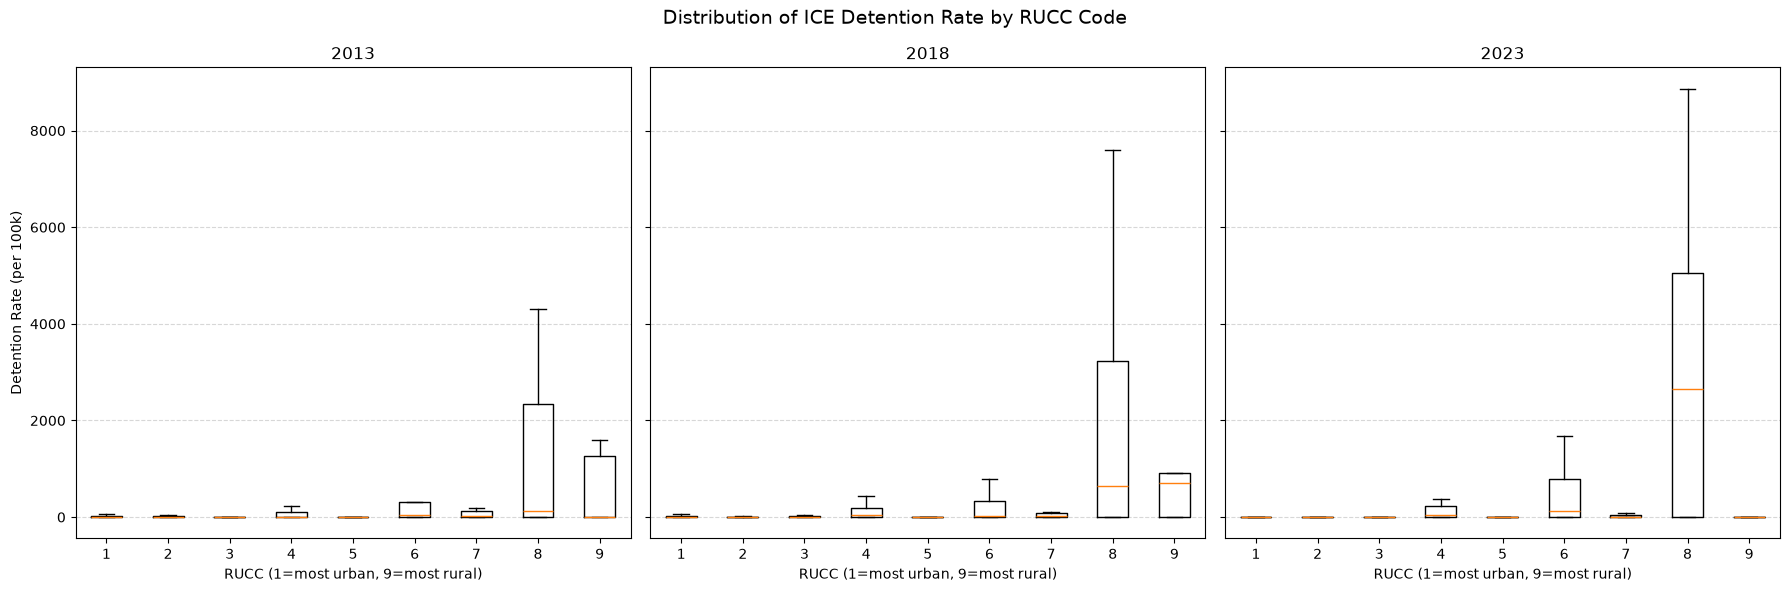

In [25]:
# Boxplot of detention rate by RUCC and year
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, yr in zip(axes, [2013, 2018, 2023]):
    sub = df_county[df_county['year'] == yr]
    sorted_rucc = sorted(sub['RUCC'].unique())
    data = [sub[(sub['RUCC'] == r) & (sub['detention_rate'] > 0)]['detention_rate'].dropna().values
            for r in sorted_rucc]
    ax.boxplot(data, showfliers=False)
    ax.set_xticks(range(1, len(sorted_rucc) + 1))
    ax.set_xticklabels(sorted_rucc)
    ax.set_title(str(yr))
    ax.set_xlabel('RUCC (1=most urban, 9=most rural)')
    if ax == axes[0]:
        ax.set_ylabel('Detention Rate (per 100k)')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Distribution of ICE Detention Rate by RUCC Code', fontsize=14)
plt.tight_layout()
plt.show()

## OLS Regression: What SES variables relate to detention? (RQ2)

In [10]:
# OLS Data Prep
SES_VARS = ['GINI', 'RiskyMobility', 'SnapRate', 'Unemployment',
            'No_HS', 'HousingQuality', 'Poverty', 'CostBurden']

reg_df = df_county.copy()
reg_df['RUCC'] = pd.Categorical(reg_df['RUCC'])
reg_df['year'] = pd.Categorical(reg_df['year'])
# Drop rows where any of the variables we use are NaNs
reg_df = reg_df.dropna(subset=SES_VARS + ['detention_rate', 'turnover_rate'])
# Add binary indicator for hosting an active facility
reg_df['is_host'] = (reg_df['detention_rate'] > 0).astype(int)
print(f"Regression data shape: {reg_df.shape}")

NameError: name 'df_county' is not defined

In [27]:
# Model 1: Logistic Regression (Probability of hosting an active facility)
formula_det = 'is_host ~ ' + ' + '.join(SES_VARS) + ' + C(RUCC) + C(year)'
model_det   = smf.logit(formula_det, data=reg_df).fit()
print(model_det.summary())

Optimization terminated successfully.
         Current function value: 0.281392
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                is_host   No. Observations:                 9311
Model:                          Logit   Df Residuals:                     9292
Method:                           MLE   Df Model:                           18
Date:                Tue, 21 Jul 2026   Pseudo R-squ.:                  0.1733
Time:                        17:33:03   Log-Likelihood:                -2620.0
converged:                       True   LL-Null:                       -3169.1
Covariance Type:            nonrobust   LLR p-value:                7.253e-222
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -6.1270      0.540    -11.355      0.000      -7.185      -5.069
C(RUCC)[T.2]  

## Model 2: Turnover rate (fitted only on hosting counties to avoid structural zeros bias)


In [28]:
# Model 2: Zero-Inflated Negative Binomial (ZINB) Model
# Replaces OLS to handle structural zeros and right-skewed detainee counts

import statsmodels.api as sm
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
import numpy as np
import pandas as pd

if "reg_df" not in locals():
    SES_VARS = ['GINI', 'RiskyMobility', 'SnapRate', 'Unemployment', 'No_HS', 'HousingQuality', 'Poverty', 'CostBurden']
    reg_df = df_county.copy()
    reg_df['RUCC'] = pd.Categorical(reg_df['RUCC'])
    reg_df['year'] = pd.Categorical(reg_df['year'])
    reg_df = reg_df.dropna(subset=SES_VARS + ['detention_rate', 'turnover_rate'])
    reg_df['is_host'] = (reg_df['detention_rate'] > 0).astype(int)

# Prepare dataset for ZINB model
zinb_df = reg_df.copy().dropna(subset=['TotalPopulation', 'GINI', 'RiskyMobility', 'SnapRate', 'Unemployment', 'No_HS', 'HousingQuality', 'Poverty', 'CostBurden', 'RUCC'])

# Target outcome: integer daily population
zinb_df['daily_pop_int'] = np.round(zinb_df['daily_pop'].fillna(0)).astype(int)

# Count model and Inflation model formulas
count_formula = "daily_pop_int ~ " + " + ".join(SES_VARS) + " + C(RUCC) + C(year)"
inflation_formula = "~ C(RUCC) + Poverty + SnapRate + CostBurden"

# Exposure offset log(TotalPopulation)
exposure = np.log(zinb_df['TotalPopulation'])

# Fit ZINB model
zinb_model = sm.ZeroInflatedNegativeBinomialP.from_formula(
    formula=count_formula,
    exog_infl=sm.df_to_exog(zinb_df, inflation_formula),
    data=zinb_df,
    offset=exposure,
    p=2
)
zinb_res = zinb_model.fit(maxiter=500, method='bfgs')
print(zinb_res.summary())

                            OLS Regression Results                            
Dep. Variable:          turnover_rate   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     3.050
Date:                Tue, 21 Jul 2026   Prob (F-statistic):           1.94e-05
Time:                        17:33:03   Log-Likelihood:                -5470.1
No. Observations:                 997   AIC:                         1.098e+04
Df Residuals:                     978   BIC:                         1.107e+04
Df Model:                          18                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         -57.9350     47.984     

## Spatial Analysis: Is detention spatially clustered? (RQ1 + extension)

In [29]:

# Build spatial weights (using 2023 geometry as reference)
# Filter out any null or empty geometries to ensure robust spatial weight building
geo_2023 = df_county[(df_county['year'] == 2023) & (df_county['geometry'].notna())].copy()
geo_2023 = gpd.GeoDataFrame(geo_2023, geometry='geometry')
geo_2023 = geo_2023[~geo_2023['geometry'].is_empty]

w = libpysal.weights.Queen.from_dataframe(geo_2023, use_index=False, silence_warnings=True)
w.transform = 'r'   # row-standardize
print(f"Number of observations: {w.n}")
print(f"Average number of neighbors: {w.mean_neighbors:.2f}")

Number of observations: 3107
Average number of neighbors: 5.83


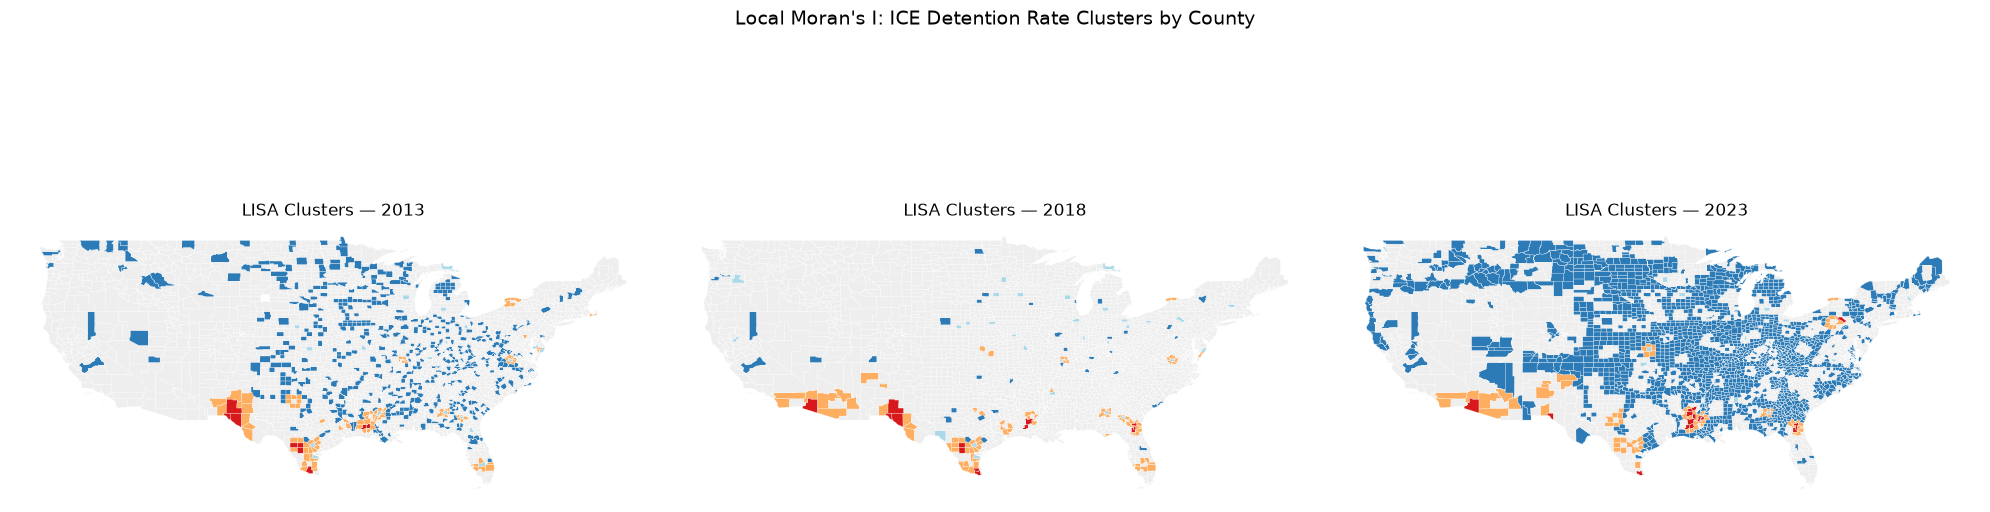

In [30]:
# LISA (Local Moran's I) per year

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, yr in zip(axes, [2013, 2018, 2023]):
    # Convert to GeoDataFrame with robust geometry filtering
    sub = df_county[(df_county['year'] == yr) & (df_county['geometry'].notna())].copy()
    sub = gpd.GeoDataFrame(sub, geometry='geometry')
    sub = sub[~sub['geometry'].is_empty].reset_index(drop=True)
    
    # Rebuild weights and filter out islands to avoid division by zero in Moran_Local
    w_yr = libpysal.weights.Queen.from_dataframe(sub, use_index=False, silence_warnings=True)
    islands = w_yr.islands
    if islands:
        non_islands = [i for i in range(len(sub)) if i not in islands]
        sub = sub.iloc[non_islands].reset_index(drop=True)
        w_yr = libpysal.weights.Queen.from_dataframe(sub, use_index=False, silence_warnings=True)
        
    w_yr.transform = 'r'
    
    # Run LISA with 99 permutations for speed
    lisa = Moran_Local(sub['detention_rate'].values, w_yr, permutations=99, seed=42)
    
    # Classify significant clusters
    sig  = lisa.p_sim < 0.05
    quad = lisa.q  # 1=HH, 2=LH, 3=LL, 4=HL
    labels = {1:'HH', 2:'LH', 3:'LL', 4:'HL'}
    colors = {1:'#d7191c', 2:'#fdae61', 3:'#2c7bb6', 4:'#abd9e9', 0:'#eeeeee'}
    
    cluster = sub.copy()
    cluster['cluster'] = [labels[q] if s else 'ns' for s, q in zip(sig, quad)]
    cluster['color']   = [colors[q] if s else colors[0] for s, q in zip(sig, quad)]
    cluster.plot(ax=ax, color=cluster['color'], edgecolor='white', linewidth=0.2)
    ax.set_title(f'LISA Clusters — {yr}')
    ax.axis('off')

plt.suptitle('Local Moran\'s I: ICE Detention Rate Clusters by County', fontsize=14)
plt.tight_layout()
plt.show()

year,2013,2018,2023
RUCC,,,
1,-0.0161,-0.0173,-0.0111
2,-0.0022,-0.0022,-0.0028
3,-0.0149,0.2397,-0.0023
4,-0.0057,0.0008,-0.0288
5,0.0132,0.0094,0.0207
6,0.0244,-0.0070,-0.0011
7,-0.0223,0.0012,0.0042
8,-0.0127,-0.0089,0.2999
9,-0.0076,-0.0020,-0.0015


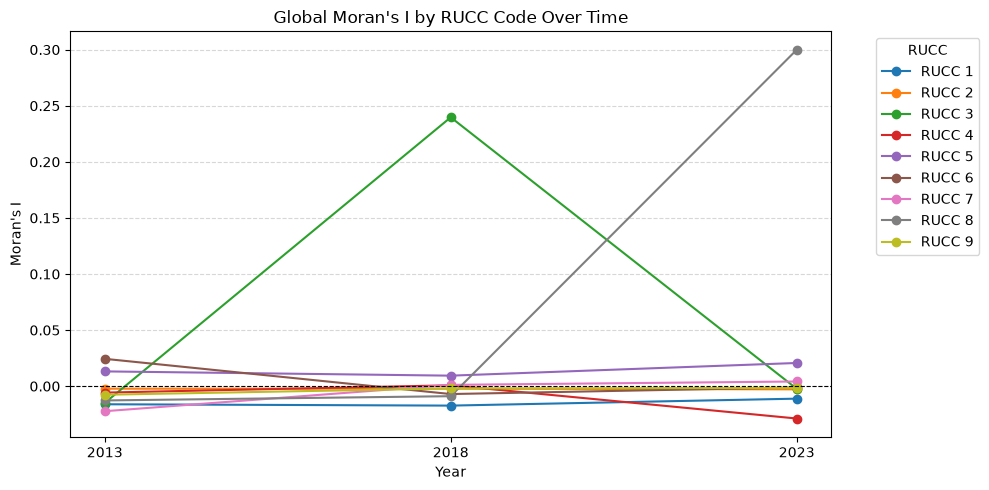

In [31]:
# Global Moran's I per RUCC per year
results = []
for yr in [2013, 2018, 2023]:
    # Convert to GeoDataFrame with robust geometry filtering
    sub_yr = df_county[(df_county['year'] == yr) & (df_county['geometry'].notna())].copy()
    sub_yr = gpd.GeoDataFrame(sub_yr, geometry='geometry')
    sub_yr = sub_yr[~sub_yr['geometry'].is_empty]
    
    for rucc in sorted(sub_yr['RUCC'].unique()):
        sub = sub_yr[sub_yr['RUCC'] == rucc].copy()
        if len(sub) < 3:  # need at least 3 polygons for weights
            continue
        try:
            w_sub = libpysal.weights.Queen.from_dataframe(sub, use_index=False, silence_warnings=True)
            w_sub.transform = 'r'
            mi = Moran(sub['detention_rate'].values, w_sub)
            results.append({'year': yr, 'RUCC': rucc,
                            "Moran's I": round(mi.I, 4), 'p': round(mi.p_sim, 4)})
        except Exception:
            pass  # isolated islands with no queen neighbors

mi_df = pd.DataFrame(results)
display(mi_df.pivot_table(index='RUCC', columns='year', values="Moran's I"))

# Line plot: Moran's I trajectory per RUCC over time
fig, ax = plt.subplots(figsize=(10, 5))
for rucc, grp in mi_df.groupby('RUCC'):
    ax.plot(grp['year'], grp["Moran's I"], marker='o', label=f'RUCC {rucc}')
ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.set_title("Global Moran's I by RUCC Code Over Time")
ax.set_xlabel('Year')
ax.set_ylabel("Moran's I")
ax.set_xticks([2013, 2018, 2023])
ax.legend(title='RUCC', bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [32]:
# Upgraded Spatial Model: Spatial Panel Durbin Model with Fixed Effects (SPDM)
# Handles both spatial dependence (W*Y, W*X) and multi-year panel data (2013, 2018, 2023)

import libpysal
from spreg import ML_LagFE

ses_cols = ['GINI', 'RiskyMobility', 'SnapRate', 'Unemployment', 'No_HS', 'HousingQuality', 'Poverty', 'CostBurden']

# 1. Filter valid rows and construct balanced panel (GEOIDs present in all 3 years)
valid_df = df_county.dropna(subset=ses_cols + ['detention_rate', 'geometry']).copy()
counts = valid_df.groupby('GEOID')['year'].nunique()
balanced_geoids = set(counts[counts == 3].index)
balanced_df = valid_df[valid_df['GEOID'].isin(balanced_geoids)].sort_values(['year', 'GEOID']).reset_index(drop=True)

# 2. Build spatial weights matrix for base year
base_year = balanced_df[balanced_df['year'] == 2013].copy().reset_index(drop=True)
base_gdf = gpd.GeoDataFrame(base_year, geometry='geometry')
w = libpysal.weights.Queen.from_dataframe(base_gdf, use_index=False, silence_warnings=True)

# Exclude islands
islands = w.islands
if islands:
    non_island_geoids = set(base_gdf.iloc[[i for i in range(len(base_gdf)) if i not in islands]]['GEOID'])
    balanced_df = balanced_df[balanced_df['GEOID'].isin(non_island_geoids)].sort_values(['year', 'GEOID']).reset_index(drop=True)
    base_year = balanced_df[balanced_df['year'] == 2013].copy().reset_index(drop=True)
    base_gdf = gpd.GeoDataFrame(base_year, geometry='geometry')
    w = libpysal.weights.Queen.from_dataframe(base_gdf, use_index=False, silence_warnings=True)

w.transform = 'r'

# 3. Compute spatial lags W * X for each year
wx_names = []
for col in ses_cols:
    w_col_all = []
    for yr in [2013, 2018, 2023]:
        yr_vals = balanced_df[balanced_df['year'] == yr][col].values
        w_col_all.append(libpysal.weights.lag_spatial(w, yr_vals))
    balanced_df[f'W_{col}'] = np.concatenate(w_col_all)
    wx_names.append(f'W_{col}')

x_vars = ses_cols + wx_names
X = balanced_df[x_vars].values
y = balanced_df['detention_rate'].values.reshape(-1, 1)

# 4. Fit Spatial Panel FE Durbin Model
sp_fe = ML_LagFE(y, X, w=w, name_y='detention_rate', name_x=x_vars, name_w='Queen_W')
print(sp_fe.summary)

ML_Lag

=================== Year 2013 Spatial Lag Model ===================
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :        2013
Weights matrix      :     unknown
Dependent Variable  :detention_rate                Number of Observations:        3099
Mean dependent var  :     32.4820                Number of Variables   :          10
S.D. dependent var  :    580.3999                Degrees of Freedom    :        3089
Pseudo R-squared    :      0.0140
Spatial Pseudo R-squared:  0.0140
Log likelihood      : -24096.1404
Sigma-square ML     : 332048.4006                Akaike info criterion :   48212.281
S.E of regression   :    576.2364                Schwarz criterion     :   48272.669

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Erro

## Facility Type Composition: Dedicated vs. Contracted (RQ3)

In [33]:
# Calculate the share of Non-Dedicated (contracted IGSA) facilities per county-year
df_hosts = df.reset_index().dropna(subset=['detention_facility_code']).copy()
df_hosts['RUCC'] = df_hosts['RUCC'].astype(int)

facility_counts = df_hosts.groupby(['year', 'GEOID']).agg(
    total_facilities=('detention_facility_code', 'nunique'),
    non_dedicated_facilities=('type_grouped', lambda x: (x == 'Non-Dedicated').sum()),
    RUCC=('RUCC', 'first')
).reset_index()

facility_counts['non_dedicated_share'] = (
    facility_counts['non_dedicated_facilities'] / facility_counts['total_facilities']
)

# Kruskal-Wallis test across RUCC codes for each year
for yr in [2013, 2018, 2023]:
    sub = facility_counts[facility_counts['year'] == yr]
    groups = [
        grp['non_dedicated_share'].dropna().values
        for _, grp in sub.groupby('RUCC')
    ]
    stat, p = stats.kruskal(*groups)
    print(f"Year {yr} Kruskal-Wallis H-test: H={stat:.2f}, p={p:.4f}")

# Display mean share of non-dedicated facilities by RUCC and year
share_table = facility_counts.pivot_table(
    index='RUCC', columns='year', values='non_dedicated_share', aggfunc='mean'
)
print("\nMean Share of Non-Dedicated (IGSA Contracted) Facilities by RUCC:")
display(share_table)

Year 2013 Kruskal-Wallis H-test: H=33.62, p=0.0000
Year 2018 Kruskal-Wallis H-test: H=33.62, p=0.0000
Year 2023 Kruskal-Wallis H-test: H=33.62, p=0.0000

Mean Share of Non-Dedicated (IGSA Contracted) Facilities by RUCC:


year,2013,2018,2023
RUCC,,,
1,0.322852,0.322852,0.322852
2,0.333073,0.333073,0.333073
3,0.343702,0.343702,0.343702
4,0.531250,0.531250,0.531250
5,0.470000,0.470000,0.470000
6,0.460386,0.460386,0.460386
7,0.469231,0.469231,0.469231
8,0.524390,0.524390,0.524390
9,0.736842,0.736842,0.736842
